# 03: Structural metrics: Exact Match and Component F1

String-level comparison of generated vs gold query, no DB. Canonicalisation (comment-strip, alpha-rename of bindings, keyword upper-casing) lives in `eval_harness.canonical`, shared with notebook 04.

- **Exact Match (EM)**: equality of canonical strings.
- **Component F1**: per-clause F1 (node labels, edge types, directions, WHERE/RETURN/ORDER, LIMIT, aggregations), macro-averaged. Diagnostic for *where* the model fails.

Metrics are computed for every target present (Cypher and AQL); the summary tables and figures below keep the two targets separate. An identity sanity test (gold vs itself -> EM=True, F1=1.0) runs first.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

import pandas as pd
from eval_harness import load_records, load_dataset, OUTPUTS_DIR
from eval_harness.config import DATASETS_DIR
from eval_harness.canonical import exact_match, component_f1

OUT_CSV = OUTPUTS_DIR / 'metrics_structural.csv'

## Identity sanity test

Feed each gold query as its own translation; EM must be True and F1 = 1.0 for every target present in the datasets.

In [2]:
identity_rows = []
for ds_path in sorted(DATASETS_DIR.glob('*.yaml')):
    for q in load_dataset(ds_path.stem):
        for target, ref in q.expected.items():
            em = exact_match(ref, ref, target)
            cf = component_f1(ref, ref, target)['overall']
            identity_rows.append((ds_path.stem, q.id, target, em, cf))
identity_df = pd.DataFrame(identity_rows, columns=['dataset','query_id','target','em','component_f1'])
n_em = int((~identity_df['em']).sum()); n_cf = int((identity_df['component_f1'] < 0.999).sum())
print(f'Identity test: {len(identity_df)} cases; EM failures: {n_em}; F1<1.0: {n_cf}')
if n_em or n_cf:
    display(identity_df[(~identity_df['em']) | (identity_df['component_f1'] < 0.999)])
    raise AssertionError('Identity sanity test failed: canonicalisation has a bug.')
print('PASS')

Identity test: 56 cases; EM failures: 0; F1<1.0: 0
PASS


## Compute on the real records

Failed translations (null `generated_query`) get zeros so the report can tell 'failed to translate' from 'translated but wrong'.

In [3]:
records = load_records(OUTPUTS_DIR)
keys = ['dataset','target','model','query_id','difficulty']
rows = []
for r in records:
    translated = r.get('generated_query'); expected = r['expected_query']; target = r['target']
    base = {k: r[k] for k in keys}
    if not translated:
        rows.append({**base, 'exact_match': False, 'component_f1_overall': 0.0,
                     'f1_node_labels': 0.0, 'f1_edge_types': 0.0, 'f1_directions': 0.0,
                     'f1_where': 0.0, 'f1_return': 0.0, 'f1_order': 0.0, 'f1_limit': 0.0,
                     'f1_aggregations': 0.0})
        continue
    em = exact_match(translated, expected, target); cf = component_f1(translated, expected, target)
    rows.append({**base, 'exact_match': em, 'component_f1_overall': cf['overall'],
                 'f1_node_labels': cf['node_labels'], 'f1_edge_types': cf['edge_types'],
                 'f1_directions': cf['directions'], 'f1_where': cf['where'], 'f1_return': cf['return'],
                 'f1_order': cf['order'], 'f1_limit': cf['limit'], 'f1_aggregations': cf['aggregations']})
struct_df = pd.DataFrame(rows)
struct_df.head(8)

,dataset,target,model,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc,aql,claude-opus-4-8,ldbc_q01,easy,False,0.985000,1.000000,1.0,1.000000,1.000,0.880000,1.000000,1.0,1.0
1,ldbc,aql,claude-opus-4-8,ldbc_q02,easy,True,1.000000,1.000000,1.0,1.000000,1.000,1.000000,1.000000,1.0,1.0
2,ldbc,aql,claude-opus-4-8,ldbc_q03,easy,False,0.975000,1.000000,1.0,1.000000,0.800,1.000000,1.000000,1.0,1.0
3,ldbc,aql,claude-opus-4-8,ldbc_q04,hard,False,0.879762,0.666667,1.0,1.000000,1.000,0.800000,0.571429,1.0,1.0
4,ldbc,aql,claude-opus-4-8,ldbc_q05,hard,False,0.780118,0.666667,1.0,0.666667,0.625,0.782609,0.500000,1.0,1.0
5,ldbc,aql,claude-opus-4-8,ldbc_q06,medium,False,0.990385,1.000000,1.0,1.000000,1.000,0.923077,1.000000,1.0,1.0
6,ldbc,aql,claude-opus-4-8,ldbc_q07,medium,False,0.949405,0.666667,1.0,1.000000,1.000,0.928571,1.000000,1.0,1.0
7,ldbc,aql,claude-opus-4-8,ldbc_q08,hard,False,0.949405,0.666667,1.0,1.000000,1.000,0.928571,1.000000,1.0,1.0


## Summaries

In [4]:
metric_cols = ['exact_match','component_f1_overall','f1_node_labels','f1_edge_types',
               'f1_directions','f1_where','f1_return','f1_order','f1_limit','f1_aggregations']
print('By dataset x target x model:')
display(struct_df.groupby(['dataset','target','model'])[metric_cols].mean())
print('By target x difficulty:')
_bd = struct_df.copy()
_bd['difficulty'] = pd.Categorical(_bd['difficulty'], ['easy','medium','hard'], ordered=True)
display(_bd.groupby(['target','difficulty'], observed=True)[metric_cols].mean())

By dataset x target x model:


exact_match  component_f1_overall  \
dataset target model                                                
ldbc    aql    claude-opus-4-8     0.071429              0.904830   
               gemma4:26b          0.214286              0.897006   
               llama3.2:latest     0.000000              0.572315   
               qwen3-coder:30b     0.000000              0.854853   
        cypher claude-opus-4-8     0.500000              0.978990   
               gemma4:26b          0.642857              0.980154   
               llama3.2:latest     0.071429              0.816617   
               qwen3-coder:30b     0.285714              0.925995   

                                f1_node_labels  f1_edge_types  f1_directions  \
dataset target model                                                           
ldbc    aql    claude-opus-4-8        0.695238       1.000000       0.940476   
               gemma4:26b             0.695238       1.000000       0.964286   
               llama3.2:latest        0.000000       0.214286       0.623810   
               qwen3-coder:30b        0.666667       0.897619       0.872336   
        cypher claude-opus-4-8        1.000000       1.000000       0.875000   
               gemma4:26b             1.000000       1.000000       0.875000   
               llama3.2:latest        0.757699       1.000000       0.516667   
               qwen3-coder:30b        0.950000       1.000000       0.767007   

                                f1_where  f1_return  f1_order  f1_limit  \
dataset target model                                                      
ldbc    aql    claude-opus-4-8  0.884524   0.863809  0.854592  1.000000   
               gemma4:26b       0.841071   0.907599  0.910714  1.000000   
               llama3.2:latest  0.503719   0.831942  0.761905  0.785714   
               qwen3-coder:30b  0.727193   0.825519  0.849490  1.000000   
        cypher claude-opus-4-8  0.979221   0.977696  1.000000  1.000000   
               gemma4:26b       0.979221   0.987013  1.000000  1.000000   
               llama3.2:latest  0.514103   0.877797  0.961905  0.928571   
               qwen3-coder:30b  0.764935   0.926015  1.000000  1.000000   

                                f1_aggregations  
dataset target model                             
ldbc    aql    claude-opus-4-8         1.000000  
               gemma4:26b              0.857143  
               llama3.2:latest         0.857143  
               qwen3-coder:30b         1.000000  
        cypher claude-opus-4-8         1.000000  
               gemma4:26b              1.000000  
               llama3.2:latest         0.976190  
               qwen3-coder:30b         1.000000

By target x difficulty:


exact_match  component_f1_overall  f1_node_labels  \
target difficulty                                                      
aql    easy           0.333333              0.937577        0.750000   
       medium         0.000000              0.818152        0.437500   
       hard           0.000000              0.745168        0.457143   
cypher easy           0.833333              0.956282        0.944444   
       medium         0.125000              0.925783        0.905032   
       hard           0.321429              0.912024        0.931926   

                   f1_edge_types  f1_directions  f1_where  f1_return  \
target difficulty                                                      
aql    easy             0.916667       0.916667  0.950000   0.967281   
       medium           0.747917       0.820833  0.812500   0.856674   
       hard             0.735714       0.838549  0.606825   0.810358   
cypher easy             1.000000       0.833333  0.886364   0.986111   
       medium           1.000000       0.764583  0.833498   0.923982   
       hard             1.000000       0.722789  0.762585   0.933652   

                   f1_order  f1_limit  f1_aggregations  
target difficulty                                       
aql    easy        1.000000  1.000000         1.000000  
       medium      0.932292  1.000000         0.937500  
       hard        0.727041  0.892857         0.892857  
cypher easy        1.000000  1.000000         1.000000  
       medium      0.979167  1.000000         1.000000  
       hard        0.992857  0.964286         0.988095

In [5]:
struct_df.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(struct_df)} rows to {OUT_CSV}')

Wrote 112 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs/metrics_structural.csv


## Visualizations: per target (Cypher and AQL kept separate)

Each target gets its own subsection: where each model is weak (per-clause F1), the per-query F1 matrix, and per-model exact match / component F1. Figures use a target prefix (`cypher_*`, `aql_*`). Grey `n/a` cells mark a model with no structural row yet (partial run).

In [6]:
from eval_harness import plots, REPORTS_DIR
FIG_DIR = REPORTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)

def render_structural(sub, prefix, label):
    """All structural figures for one target only (prefix -> figure filenames)."""
    if sub.empty:
        print(f'No {label} records to plot.'); return
    models = plots.model_axis(sub); queries = plots.query_axis(sub)
    print(f'{label}: {len(models)} model(s): {models}')
    p = FIG_DIR / f'{prefix}_component_f1.png'
    plots.component_f1_by_model(sub, path=p); plots.show(p)
    p = FIG_DIR / f'{prefix}_query_model_f1.png'
    plots.query_model_heatmap(sub, 'component_f1_overall', p, models=models, queries=queries,
                              title=f'{label}: component F1 by query x model', cbar_label='F1')
    plots.show(p)
    p = FIG_DIR / f'{prefix}_structural_bars.png'
    plots.per_model_bars(sub, ['exact_match', 'component_f1_overall'], p,
                         title=f'{label}: exact match and component F1 per model', ylabel='score',
                         labels={'exact_match': 'exact match', 'component_f1_overall': 'component F1'})
    plots.show(p)

### SQL → Cypher

SQL -> Cypher: 4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


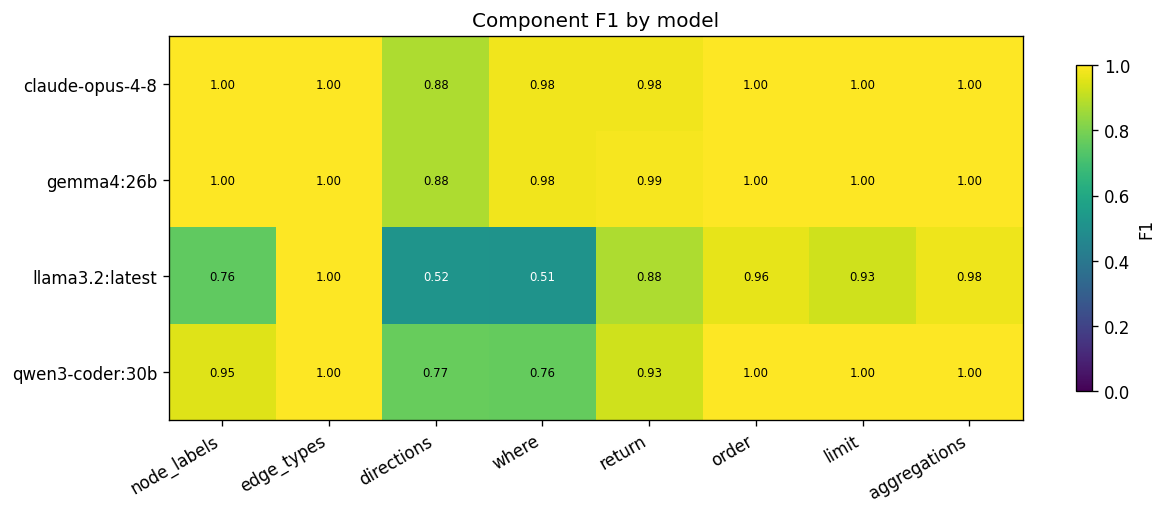

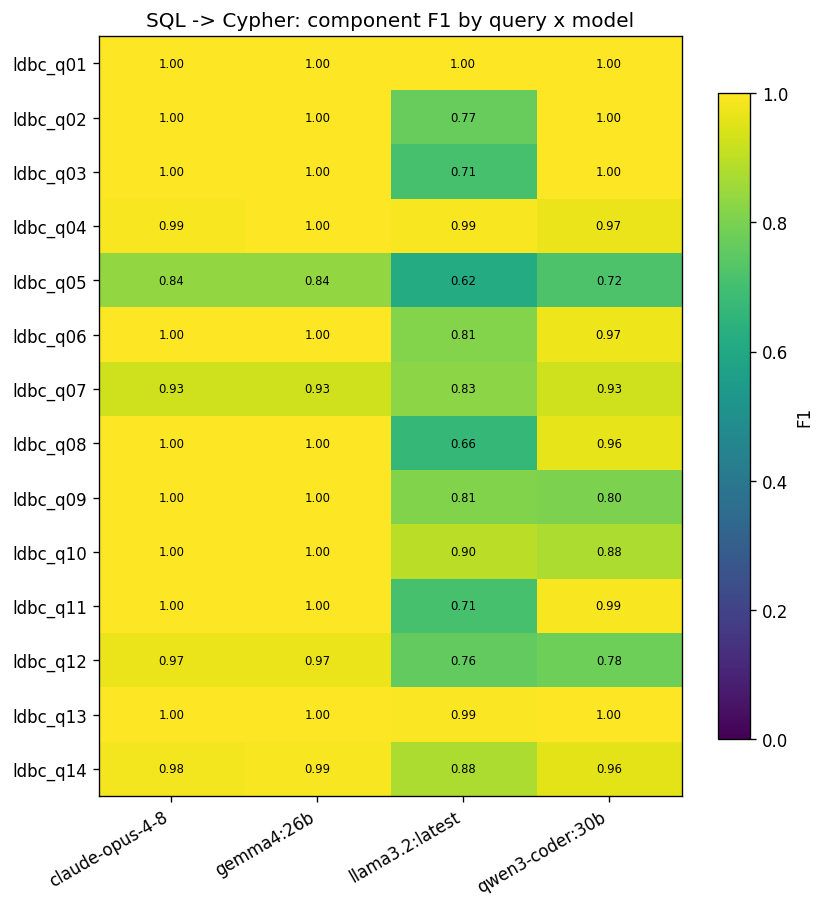

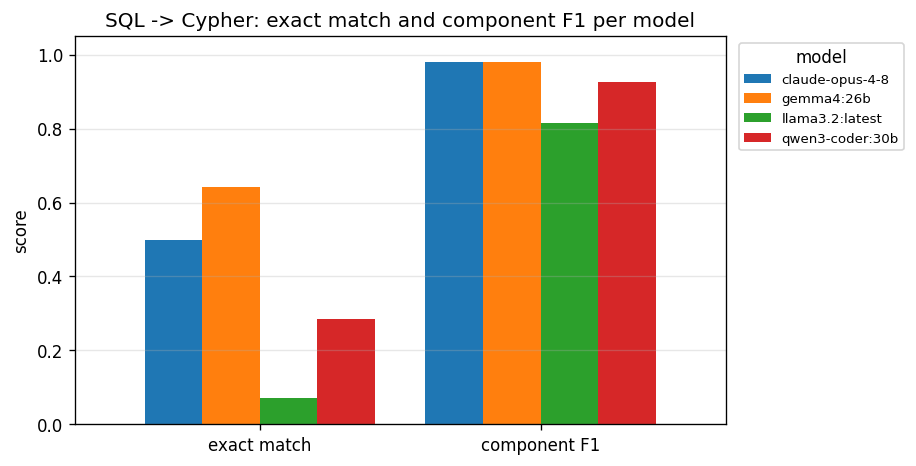

In [7]:
render_structural(struct_df[struct_df['target'] == 'cypher'], 'cypher', 'SQL -> Cypher')

### SQL → AQL

SQL -> AQL: 4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


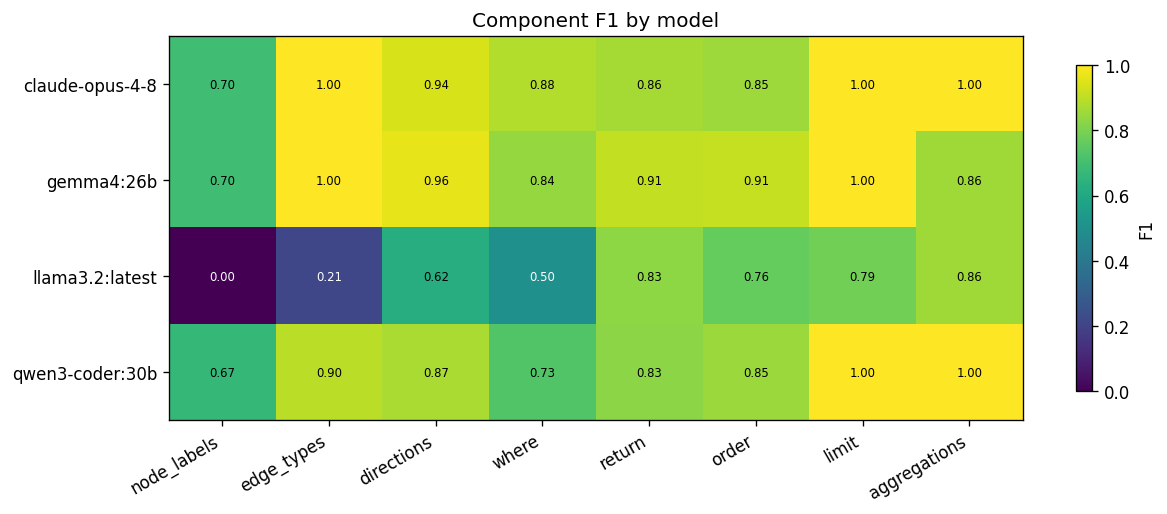

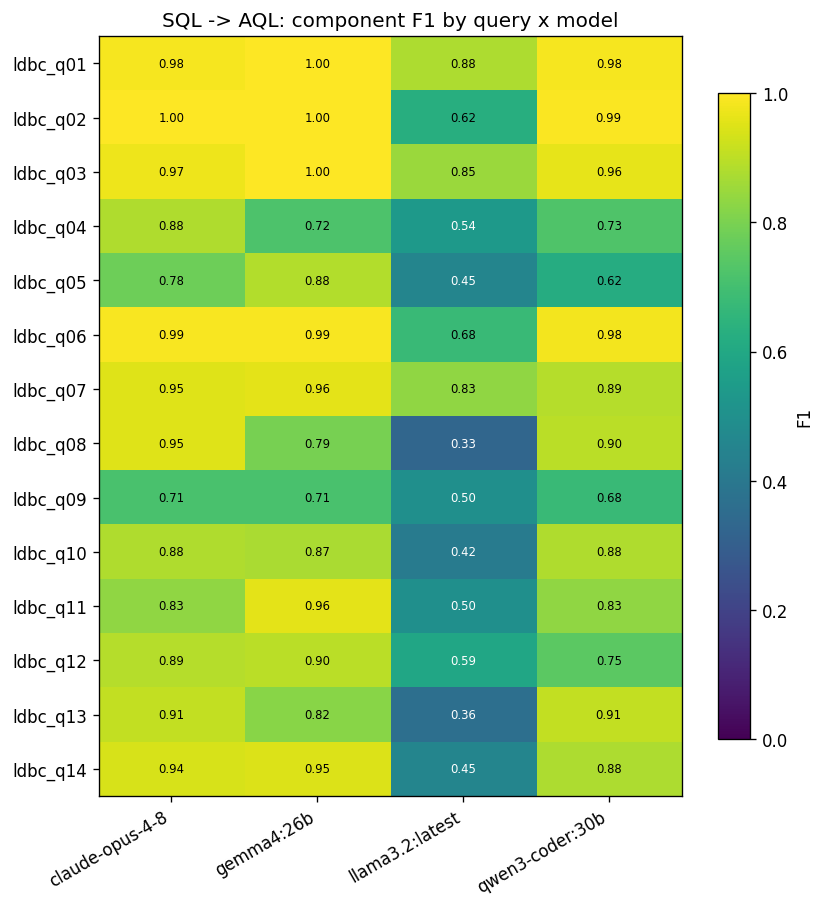

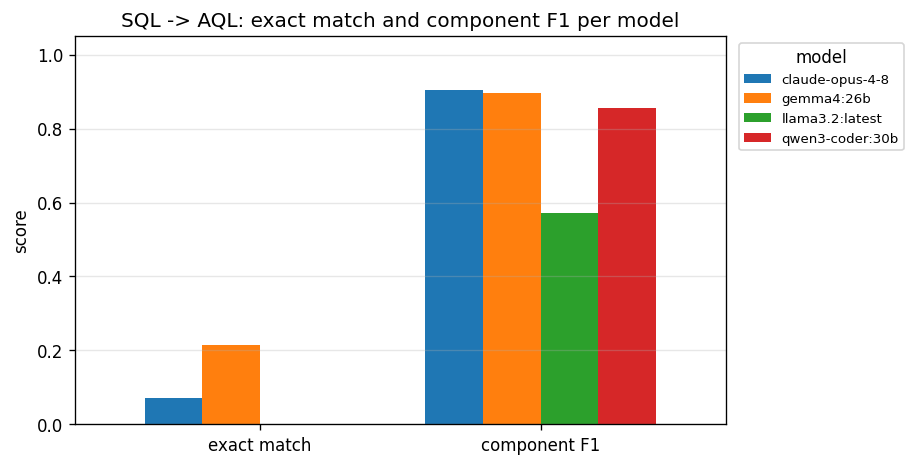

In [8]:
render_structural(struct_df[struct_df['target'] == 'aql'], 'aql', 'SQL -> AQL')